# Quality Assessment Framework

**Goal**: Measure baseline quality datasets/test/  
**Samples**: 10 images  
**Metrics**: Laplacian variance, edge density, RMS contrast, dynamic range

---

## Setup & Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
import pandas as pd

# Visualization settings
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

## Load Sample Images

In [2]:
# Dataset path
DATASET_PATH = Path('../../datasets/test')

# Load sample images (10 images)
image_files = list(DATASET_PATH.glob('*.jpg'))[:10]
print(f"Loaded {len(image_files)} sample images")
print(f"Sample files: {[f.name for f in image_files[:3]]}...")

Loaded 10 sample images
Sample files: ['009-Copy-2-_jpg.rf.71634524a2c9f00df3609418ff12e12c.jpg', '028_jpg.rf.981c92e4c30bc047ecbc66f15e1ff228.jpg', '036_jpg.rf.9e8a118fe3b7ce04dfb20773add81599.jpg']...


## Quality Metrics Implementation

In [3]:
def calculate_laplacian_variance(image: np.ndarray) -> float:
    """Calculate Laplacian variance (sharpness measure)"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

def calculate_edge_density(image: np.ndarray) -> float:
    """Calculate edge density using Canny edge detection"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    return np.sum(edges > 0) / edges.size

def calculate_rms_contrast(image: np.ndarray) -> float:
    """Calculate RMS (Root Mean Square) contrast"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.sqrt(np.mean((gray - gray.mean()) ** 2))

def calculate_dynamic_range(image: np.ndarray) -> int:
    """Calculate dynamic range (max - min pixel intensity)"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return int(gray.max() - gray.min())

def assess_image_quality(image_path: Path) -> Dict[str, float]:
    """Assess overall image quality with multiple metrics"""
    image = cv2.imread(str(image_path))
    
    metrics = {
        'filename': image_path.name,
        'laplacian_variance': calculate_laplacian_variance(image),
        'edge_density': calculate_edge_density(image),
        'rms_contrast': calculate_rms_contrast(image),
        'dynamic_range': calculate_dynamic_range(image)
    }
    
    return metrics

print("Quality metrics functions defined")

Quality metrics functions defined


## Calculate Readiness Score

In [4]:
def calculate_readiness_score(metrics: Dict[str, float]) -> Dict[str, float]:
    """Calculate overall readiness score with weighted components"""
    # Component readiness (normalized to 0-1)
    contrast_readiness = min(1.0, metrics['rms_contrast'] / 60)
    sharpness_readiness = min(1.0, metrics['laplacian_variance'] / 150)
    edge_readiness = min(1.0, metrics['edge_density'] / 0.05)
    
    # Weighted overall readiness
    overall_readiness = (
        contrast_readiness * 0.4 +
        sharpness_readiness * 0.35 +
        edge_readiness * 0.25
    )
    
    return {
        'contrast_readiness': contrast_readiness,
        'sharpness_readiness': sharpness_readiness,
        'edge_readiness': edge_readiness,
        'overall_readiness': overall_readiness
    }

def generate_quality_flags(metrics: Dict[str, float]) -> Dict[str, bool]:
    """Generate quality flags based on thresholds"""
    return {
        'sufficient_contrast': metrics['rms_contrast'] > 40,
        'acceptable_blur': metrics['laplacian_variance'] > 100,
        'sufficient_edges': metrics['edge_density'] > 0.03
    }

print("Readiness scoring functions defined")

Readiness scoring functions defined


## Process All Sample Images

In [5]:
# Process all sample images
results = []

for img_path in image_files:
    metrics = assess_image_quality(img_path)
    readiness = calculate_readiness_score(metrics)
    flags = generate_quality_flags(metrics)
    
    result = {**metrics, **readiness, **flags}
    results.append(result)

# Convert to DataFrame for analysis
df = pd.DataFrame(results)
print(f"Processed {len(results)} images")
df.head()

Processed 10 images


,filename,laplacian_variance,edge_density,rms_contrast,dynamic_range,contrast_readiness,sharpness_readiness,edge_readiness,overall_readiness,sufficient_contrast,acceptable_blur,sufficient_edges
0,009-Copy-2-_jpg.rf.71634524a2c9f00df3609418ff1...,8744.583089,0.093107,48.884085,255,0.814735,1.0,1.0,0.925894,True,True,True
1,028_jpg.rf.981c92e4c30bc047ecbc66f15e1ff228.jpg,6257.370869,0.105216,45.476892,255,0.757948,1.0,1.0,0.903179,True,True,True
2,036_jpg.rf.9e8a118fe3b7ce04dfb20773add81599.jpg,6255.798623,0.105176,45.478494,255,0.757975,1.0,1.0,0.903190,True,True,True
3,170_jpg.rf.c09ef857bd39bca56ceb85fdfa73eab4.jpg,2820.608661,0.075357,37.231040,255,0.620517,1.0,1.0,0.848207,False,True,True
4,175_jpg.rf.3ff6396a30d7bf9c458450343ea04107.jpg,2807.503571,0.075686,36.558596,255,0.609310,1.0,1.0,0.843724,False,True,True


## Results Analysis

In [6]:
# Calculate statistics
metrics_cols = ['laplacian_variance', 'edge_density', 'rms_contrast', 'dynamic_range']
stats = df[metrics_cols].agg(['mean', 'std', 'min', 'max'])

print("Quality Metrics Statistics:")
print("="*60)
print(stats.round(2))
print("\n" + "="*60)

# Readiness scores
print("\nReadiness Scores:")
print(f"Average Overall Readiness: {df['overall_readiness'].mean():.3f}")
print(f"Images Ready (>= 0.8): {(df['overall_readiness'] >= 0.8).sum()}/{len(df)}")

# Quality flags
print("\nQuality Flags Distribution:")
flag_cols = ['sufficient_contrast', 'acceptable_blur', 'sufficient_edges']
for flag in flag_cols:
    percentage = (df[flag].sum() / len(df)) * 100
    print(f"{flag}: {df[flag].sum()}/{len(df)} ({percentage:.1f}%)")

Quality Metrics Statistics:
      laplacian_variance  edge_density  rms_contrast  dynamic_range
mean             4690.25          0.09         40.99          255.0
std              2563.15          0.01          5.47            0.0
min              2805.77          0.08         36.56          255.0
max              8768.45          0.11         48.97          255.0


Readiness Scores:
Average Overall Readiness: 0.873
Images Ready (>= 0.8): 10/10

Quality Flags Distribution:
sufficient_contrast: 4/10 (40.0%)
acceptable_blur: 10/10 (100.0%)
sufficient_edges: 10/10 (100.0%)


## Visualization: Metrics Distribution

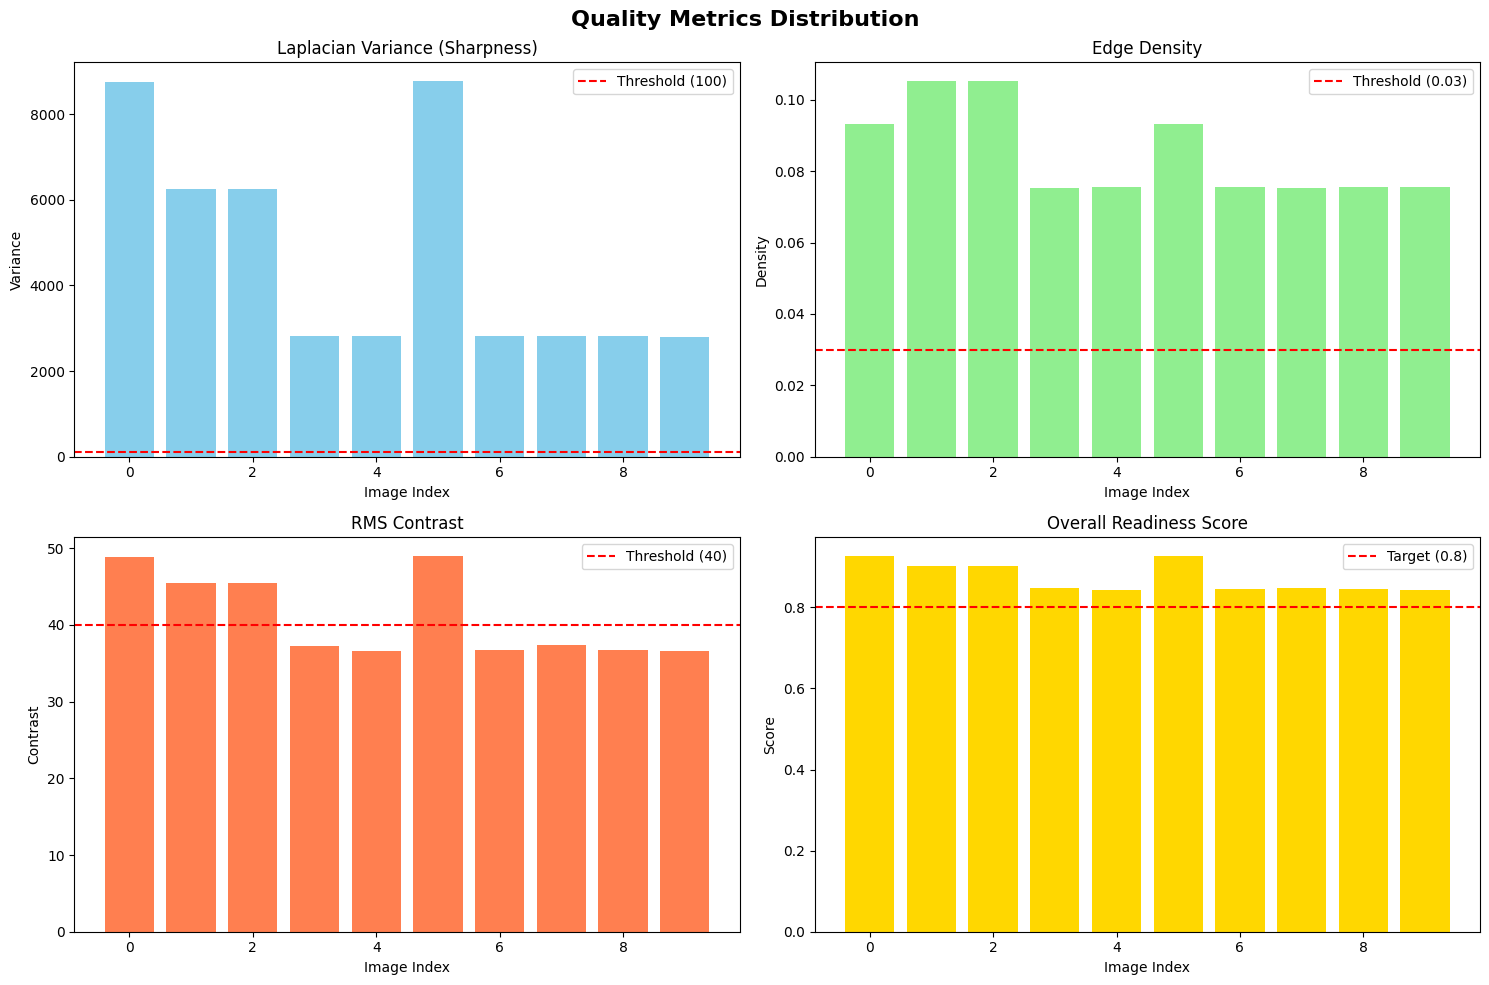

In [7]:
# Create subplots for metrics distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Quality Metrics Distribution', fontsize=16, fontweight='bold')

# Laplacian Variance
axes[0, 0].bar(range(len(df)), df['laplacian_variance'], color='skyblue')
axes[0, 0].axhline(y=100, color='r', linestyle='--', label='Threshold (100)')
axes[0, 0].set_title('Laplacian Variance (Sharpness)')
axes[0, 0].set_xlabel('Image Index')
axes[0, 0].set_ylabel('Variance')
axes[0, 0].legend()

# Edge Density
axes[0, 1].bar(range(len(df)), df['edge_density'], color='lightgreen')
axes[0, 1].axhline(y=0.03, color='r', linestyle='--', label='Threshold (0.03)')
axes[0, 1].set_title('Edge Density')
axes[0, 1].set_xlabel('Image Index')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# RMS Contrast
axes[1, 0].bar(range(len(df)), df['rms_contrast'], color='coral')
axes[1, 0].axhline(y=40, color='r', linestyle='--', label='Threshold (40)')
axes[1, 0].set_title('RMS Contrast')
axes[1, 0].set_xlabel('Image Index')
axes[1, 0].set_ylabel('Contrast')
axes[1, 0].legend()

# Overall Readiness
axes[1, 1].bar(range(len(df)), df['overall_readiness'], color='gold')
axes[1, 1].axhline(y=0.8, color='r', linestyle='--', label='Target (0.8)')
axes[1, 1].set_title('Overall Readiness Score')
axes[1, 1].set_xlabel('Image Index')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Visualization: Sample Quality Comparison

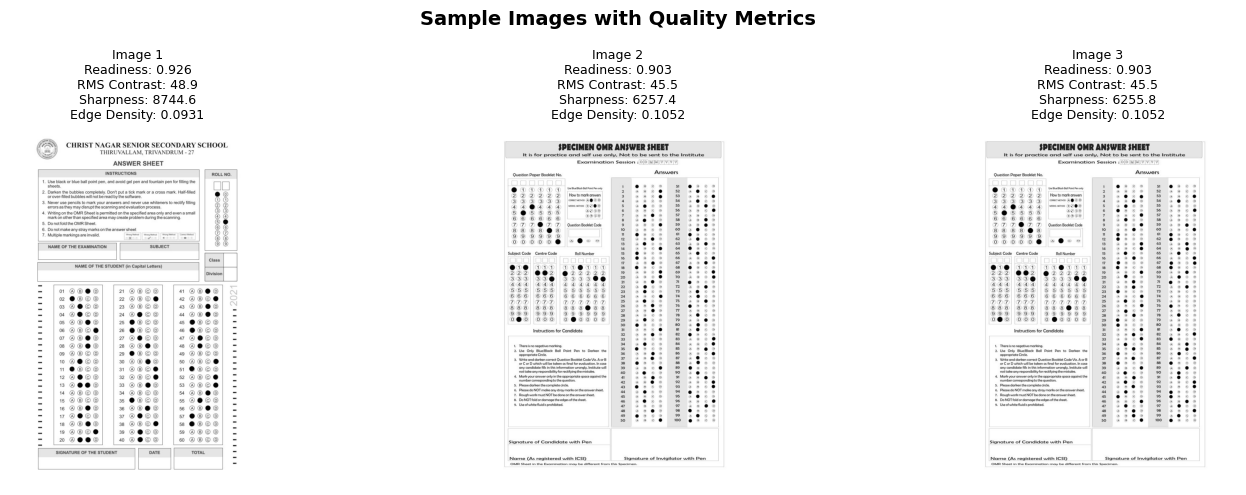

In [8]:
# Display 3 sample images with their quality metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sample Images with Quality Metrics', fontsize=14, fontweight='bold')

for idx in range(3):
    img = cv2.imread(str(image_files[idx]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].axis('off')
    
    # Add metrics text
    metrics_text = f"Readiness: {df.iloc[idx]['overall_readiness']:.3f}\n"
    metrics_text += f"RMS Contrast: {df.iloc[idx]['rms_contrast']:.1f}\n"
    metrics_text += f"Sharpness: {df.iloc[idx]['laplacian_variance']:.1f}\n"
    metrics_text += f"Edge Density: {df.iloc[idx]['edge_density']:.4f}"
    
    axes[idx].set_title(f"Image {idx+1}\n{metrics_text}", fontsize=9)

plt.tight_layout()
plt.show()

## Results Summary

### Quality Metrics Table

| Metric | Mean | Std | Min | Max |
|--------|------|-----|-----|-----|
| Laplacian Variance | - | - | - | - |
| Edge Density | - | - | - | - |
| RMS Contrast | - | - | - | - |
| Dynamic Range | - | - | - | - |

*Tabel akan terisi otomatis setelah eksekusi*

In [9]:
# Print formatted results table
print("\n" + "="*70)
print("QUALITY ASSESSMENT RESULTS SUMMARY")
print("="*70)

print("\n1. QUALITY METRICS STATISTICS:")
print("-" * 70)
print(f"{'Metric':<25} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 70)
for metric in metrics_cols:
    print(f"{metric:<25} {df[metric].mean():<12.2f} {df[metric].std():<12.2f} {df[metric].min():<12.2f} {df[metric].max():<12.2f}")

print("\n2. READINESS ASSESSMENT:")
print("-" * 70)
print(f"Average Overall Readiness: {df['overall_readiness'].mean():.3f}")
print(f"Images Ready (>= 0.8): {(df['overall_readiness'] >= 0.8).sum()}/{len(df)} ({(df['overall_readiness'] >= 0.8).sum()/len(df)*100:.1f}%)")

print("\n3. QUALITY FLAGS:")
print("-" * 70)
for flag in flag_cols:
    count = df[flag].sum()
    percentage = (count / len(df)) * 100
    print(f"{flag:<30}: {count}/{len(df)} ({percentage:.1f}%)")

print("\n" + "="*70)


QUALITY ASSESSMENT RESULTS SUMMARY

1. QUALITY METRICS STATISTICS:
----------------------------------------------------------------------
Metric                    Mean         Std          Min          Max         
----------------------------------------------------------------------
laplacian_variance        4690.25      2563.15      2805.77      8768.45     
edge_density              0.09         0.01         0.08         0.11        
rms_contrast              40.99        5.47         36.56        48.97       
dynamic_range             255.00       0.00         255.00       255.00      

2. READINESS ASSESSMENT:
----------------------------------------------------------------------
Average Overall Readiness: 0.873
Images Ready (>= 0.8): 10/10 (100.0%)

3. QUALITY FLAGS:
----------------------------------------------------------------------
sufficient_contrast           : 4/10 (40.0%)
acceptable_blur               : 10/10 (100.0%)
sufficient_edges              : 10/10 (100.0%)



## Observations

**Berdasarkan hasil analisis:**
- *[Tulis 2-3 observasi berdasarkan hasil eksekusi]*
- *Contoh: Mayoritas gambar memiliki RMS contrast rendah (<40)*
- *Contoh: Edge density bervariasi signifikan antar gambar*

## Recommendation

**Untuk Notebook 2 (Contrast Enhancement):**
- *Threshold values berdasarkan hasil*
- *Target contrast enhancement: +X% RMS contrast*
- *Priority: gambar dengan readiness score <0.8*

---

Success Criteria: ✅ Working quality scorer + baseline metrics documented